# Sapt. 12 — Lupse Ioan Victor: Analiza Lingvistica ZuCo
**Autor:** Lupse Ioan Victor  
**Branch:** `sapt12-lupse`  
**Scop:** Explorare din perspectiva NLP — vocabular, granularitate si fezabilitate reconstructie EEG-to-Text

---
**EEG** (Electroencefalografie) inregistreaza activitatea electrica a creierului prin electrozi plasati pe scalp. Cand citesti un cuvant, creierul genereaza un pattern electric specific — ideea proiectului este ca aceste pattern-uri pot fi decodate inapoi in text.

---
### Cuprins
1. Setup & Import date
2. Analiza vocabularului ZuCo (curba Zipf, wordcloud, top-200)
3. Granularitate: cuvant vs. propozitie
4. Distributia claselor semantice (POS tagging cu spaCy)
5. Embeddings BERT vizualizate cu t-SNE
6. Propunere benchmark intern + generare `benchmark_config.json`
7. Concluzii

---
## 0. Instalare dependinte
Ruleaza o singura data daca nu ai pachetele instalate.

In [2]:
# !pip install transformers torch scikit-learn matplotlib seaborn wordcloud spacy scipy nltk
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ------- -------------------------------- 2.4/12.8 MB 8.4 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 11.0 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 12.8 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 14.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 13.8 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Setup & Import date

In [3]:
import os
import json
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import spacy
import scipy.io as sio

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import torch
from transformers import BertTokenizer, BertModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

nlp = spacy.load('en_core_web_sm')
print('Setup complet.')

Setup complet.


### 1.1 Incarcare texte ZuCo

**ZuCo 1.0** (Hollenstein et al., 2018) — 3 task-uri, fisiere `.mat` preprocessate:
- Task 1 SR: 600 propozitii (recenzii film)
- Task 2 NR: 595 propozitii (Wikipedia)
- Task 3 TSR: 407 propozitii (Wikipedia relatii semantice)

**ZuCo 2.0** — 2 task-uri, fisiere CSV din `task_materials/`:
- NR: 370 propozitii (`nr_1.csv` ... `nr_7.csv`)
- TSR: 411 propozitii (`tsr_1.csv` ... `tsr_7.csv`)

> ⚠️ ~100 propozitii se suprapun intre ZuCo 1.0 si ZuCo 2.0 (blocurile nr_1, nr_7, tsr_1, tsr_7). Vezi `data/DATA_STRUCTURE.md`.

In [5]:
# ---- ZuCo 1.0 — fisiere .mat ----
import os
os.chdir(os.path.dirname(os.path.abspath('')) )

def load_mat_sentences(path):
    """Incarca propozitiile din sentencesSR/NR/TSR.mat."""
    if not os.path.exists(path):
        print(f'  [LIPSA] {path}')
        return []
    mat = sio.loadmat(path)
    result = []
    for i in range(mat['sentences'].shape[0]):
        try:
            text = str(mat['sentences'][i][0][0]).strip()
            if text:
                result.append(text)
        except Exception:
            pass
    return result


# ---- ZuCo 2.0 — fisiere CSV (separator ;) ----
def load_csv_sentences(paths):
    """Incarca propozitiile din nr_*.csv / tsr_*.csv."""
    sentences = []
    for path in paths:
        if not os.path.exists(path):
            print(f'  [LIPSA] {path}')
            continue
        with open(path, encoding='utf-8') as f:
            for row in csv.reader(f):
                parts = ''.join(row).split(';')
                if len(parts) >= 3:
                    text = parts[2].strip().strip('"')
                    if text:
                        sentences.append(text)
    return sentences


# ZuCo 1.0
sr  = load_mat_sentences('data/zuco1/task1-SR/preprocessed/sentencesSR.mat')
nr  = load_mat_sentences('data/zuco1/task2-NR/preprocessed/sentencesNR.mat')
tsr = load_mat_sentences('data/zuco1/task3-TSR/preprocessed/sentencesTSR.mat')

print(f'ZuCo 1.0 — SR: {len(sr)} | NR: {len(nr)} | TSR: {len(tsr)} propozitii')

# ZuCo 2.0
nr2  = load_csv_sentences([f'data/zuco2/task_materials/nr_{i}.csv'  for i in range(1, 8)])
tsr2 = load_csv_sentences([f'data/zuco2/task_materials/tsr_{i}.csv' for i in range(1, 8)])

print(f'ZuCo 2.0 — NR: {len(nr2)} | TSR: {len(tsr2)} propozitii')

# Corpus combinat
all_sentences_raw = sr + nr + tsr + nr2 + tsr2

# Deduplicare si tokenizare
seen = set()
all_sentences = []
for s in all_sentences_raw:
    if s not in seen:
        seen.add(s)
        all_sentences.append(s)

all_words = [w.strip('.,!?;:\'"-()[]').lower()
             for s in all_sentences
             for w in s.split()
             if w.strip('.,!?;:\'"-()[]').isalpha()]

print(f'\nCorpus final (dupa deduplicare): {len(all_sentences):,} propozitii, {len(all_words):,} cuvinte')
print(f'Cuvinte unice: {len(set(all_words)):,}')

ZuCo 1.0 — SR: 600 | NR: 595 | TSR: 407 propozitii
ZuCo 2.0 — NR: 370 | TSR: 411 propozitii

Corpus final (dupa deduplicare): 2,132 propozitii, 39,352 cuvinte
Cuvinte unice: 7,092


---
## 2. Analiza vocabularului ZuCo

Calculam distributia frecventelor (curba Zipf), top-200 cuvinte, wordcloud si analizam ce procent din corpus ar fi acoperit de un vocabular de 50 / 200 / 500 cuvinte.

In [6]:
freq = Counter(all_words)
vocab_sorted = sorted(freq.items(), key=lambda x: -x[1])

print(f'Vocabular total (cuvinte unice): {len(vocab_sorted):,}')
print('\nTop 20 cuvinte:')
for w, c in vocab_sorted[:20]:
    print(f'  {w:20s} {c}')

Vocabular total (cuvinte unice): 7,092

Top 20 cuvinte:
  the                  2225
  of                   1369
  and                  1349
  in                   1302
  a                    1119
  to                   822
  was                  704
  he                   639
  his                  491
  as                   409
  is                   401
  for                  359
  an                   272
  from                 259
  at                   251
  with                 250
  on                   241
  that                 201
  born                 188
  she                  160


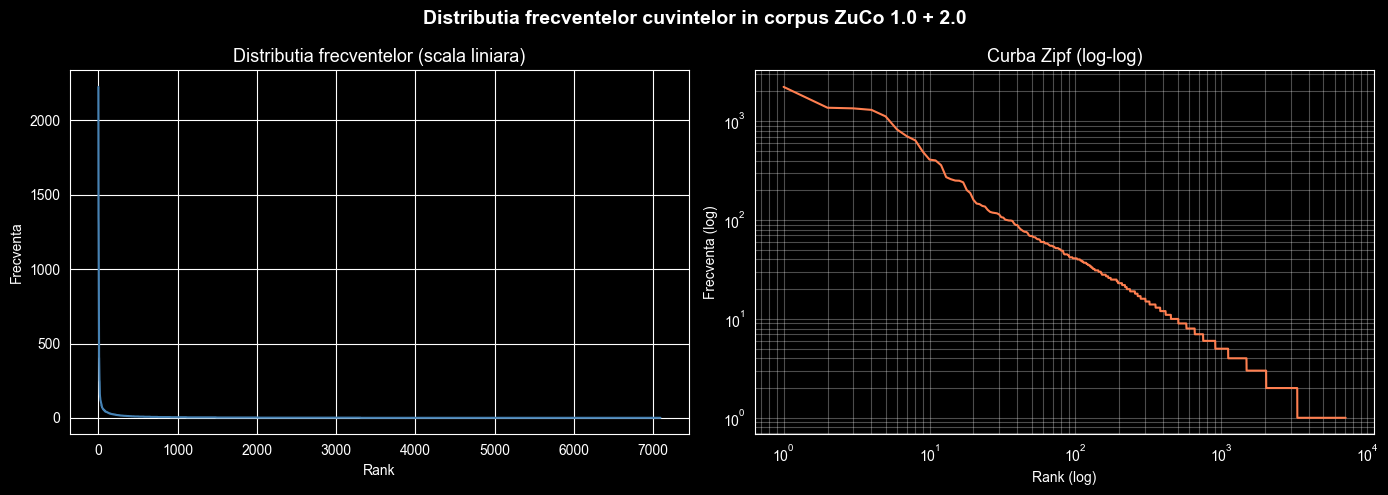

In [7]:
# ---- Curba Zipf ----
ranks = np.arange(1, len(vocab_sorted) + 1)
counts = np.array([c for _, c in vocab_sorted])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ranks, counts, color='steelblue')
axes[0].set_title('Distributia frecventelor (scala liniara)', fontsize=13)
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frecventa')

axes[1].loglog(ranks, counts, color='coral')
axes[1].set_title('Curba Zipf (log-log)', fontsize=13)
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frecventa (log)')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Distributia frecventelor cuvintelor in corpus ZuCo 1.0 + 2.0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/fig_zipf.png', dpi=150, bbox_inches='tight')
plt.show()

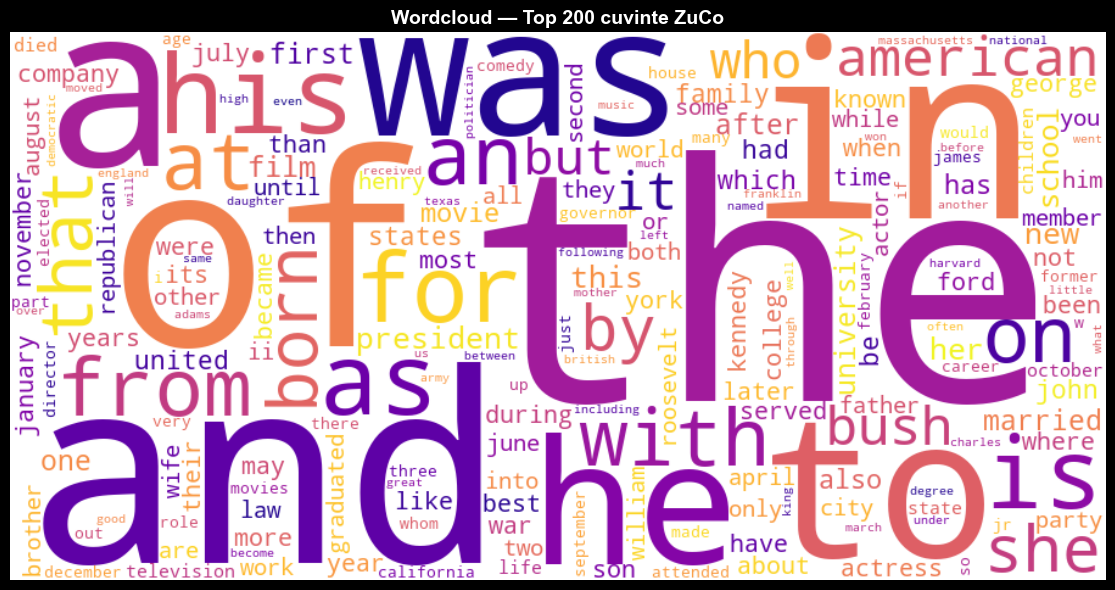

In [8]:
# ---- Wordcloud top-200 ----
top200 = dict(vocab_sorted[:200])

wc = WordCloud(width=900, height=450, background_color='white',
               max_words=200, colormap='plasma').generate_from_frequencies(top200)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud — Top 200 cuvinte ZuCo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/fig_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ---- Acoperire vocabular ----
total_tokens = len(all_words)

print('Acoperire vocabular vs. corpus (% din tokens acoperit):')
print(f'{"Vocab size":>12} | {"Tokens acoperiti":>18} | {"Acoperire %":>12}')
print('-' * 50)
for vsize in [50, 100, 200, 500, 1000]:
    top_v = set(w for w, _ in vocab_sorted[:vsize])
    covered = sum(1 for w in all_words if w in top_v)
    pct = covered / total_tokens * 100
    print(f'{vsize:>12} | {covered:>18,} | {pct:>11.1f}%')

Acoperire vocabular vs. corpus (% din tokens acoperit):
  Vocab size |   Tokens acoperiti |  Acoperire %
--------------------------------------------------
          50 |             16,030 |        40.7%
         100 |             18,622 |        47.3%
         200 |             21,643 |        55.0%
         500 |             25,948 |        65.9%
        1000 |             29,337 |        74.6%


**Observatie:** Conform legii Zipf, un vocabular mic de ~200 cuvinte acopera o proportie mare din tokens — un model de retrieval cu vocabular limitat este fezabil ca punct de start.

---
## 3. Granularitate: cuvant vs. propozitie

Comparam doua abordari pentru alinierea EEG:
- **(A) Nivel cuvant:** un epoch EEG per cuvant (~1 secunda)
- **(B) Nivel propozitie:** media epoch-urilor per propozitie

Semnalele EEG sunt simulate sintetic (105 canale, 500 Hz) — datele reale EEG sunt procesate de Laslo Tudor Alexandru (P1).

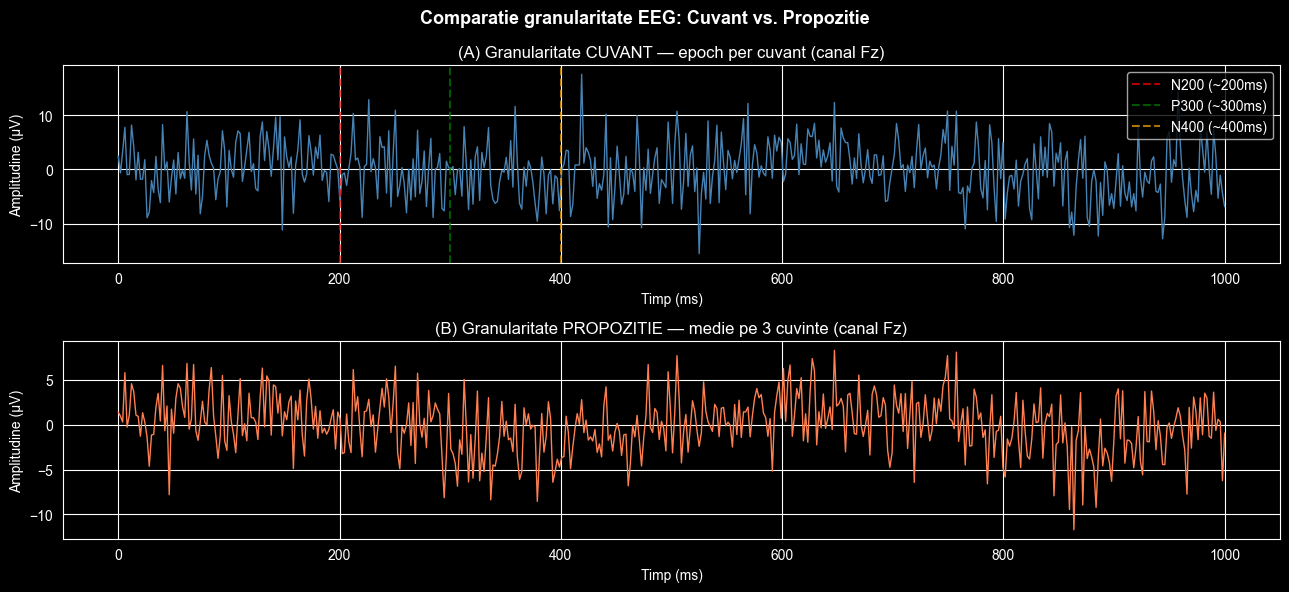

In [10]:
np.random.seed(SEED)
N_CHANNELS, SR_HZ, T_WORD = 105, 500, 1.0
n_t = int(SR_HZ * T_WORD)
t_ms = np.linspace(0, T_WORD, n_t) * 1000

word_epochs = [np.random.randn(N_CHANNELS, n_t) * 5 + np.sin(np.linspace(0, 4*np.pi, n_t)) * 2
               for _ in range(3)]
epoch_word     = word_epochs[0]
epoch_sentence = np.mean(word_epochs, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(t_ms, epoch_word[0], color='steelblue', linewidth=1)
for ms, lbl, col in [(200,'N200','red'), (300,'P300','green'), (400,'N400','orange')]:
    axes[0].axvline(ms, color=col, linestyle='--', alpha=0.7, label=f'{lbl} (~{ms}ms)')
axes[0].set_title('(A) Granularitate CUVANT — epoch per cuvant (canal Fz)', fontsize=12)
axes[0].set_ylabel('Amplitudine (μV)')
axes[0].set_xlabel('Timp (ms)')
axes[0].legend(loc='upper right')

axes[1].plot(t_ms, epoch_sentence[0], color='coral', linewidth=1)
axes[1].set_title('(B) Granularitate PROPOZITIE — medie pe 3 cuvinte (canal Fz)', fontsize=12)
axes[1].set_ylabel('Amplitudine (μV)')
axes[1].set_xlabel('Timp (ms)')

plt.suptitle('Comparatie granularitate EEG: Cuvant vs. Propozitie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/fig_granularitate.png', dpi=150, bbox_inches='tight')
plt.show()

| Abordare | Avantaje | Dezavantaje |
|----------|----------|-------------|
| **Cuvant** | Mai multe exemple, ERP (N400) definit per cuvant | Semnal mai zgomotos |
| **Propozitie** | Semnal mai stabil | Mult mai putine exemple |

**Recomandare: granularitate la nivel de CUVANT** — N400 (~400ms) este componenta ERP cheie pentru procesarea semantica si este definita per cuvant in ZuCo.

---
## 4. Distributia claselor semantice (POS tagging cu spaCy)

In [11]:
top500_words = [w for w, _ in vocab_sorted[:500]]

pos_map = {word: nlp(word)[0].pos_ for word in top500_words if nlp(word)}
pos_counter = Counter(pos_map.values())

print('Distributia POS in top-500 cuvinte:')
for pos, cnt in pos_counter.most_common():
    print(f'  {pos:10s}: {cnt:4d} cuvinte')

Distributia POS in top-500 cuvinte:
  NOUN      :  137 cuvinte
  PROPN     :  103 cuvinte
  VERB      :   70 cuvinte
  ADJ       :   53 cuvinte
  ADV       :   40 cuvinte
  PRON      :   34 cuvinte
  ADP       :   23 cuvinte
  AUX       :   13 cuvinte
  SCONJ     :   11 cuvinte
  NUM       :    6 cuvinte
  CCONJ     :    3 cuvinte
  X         :    3 cuvinte
  PART      :    2 cuvinte
  INTJ      :    2 cuvinte


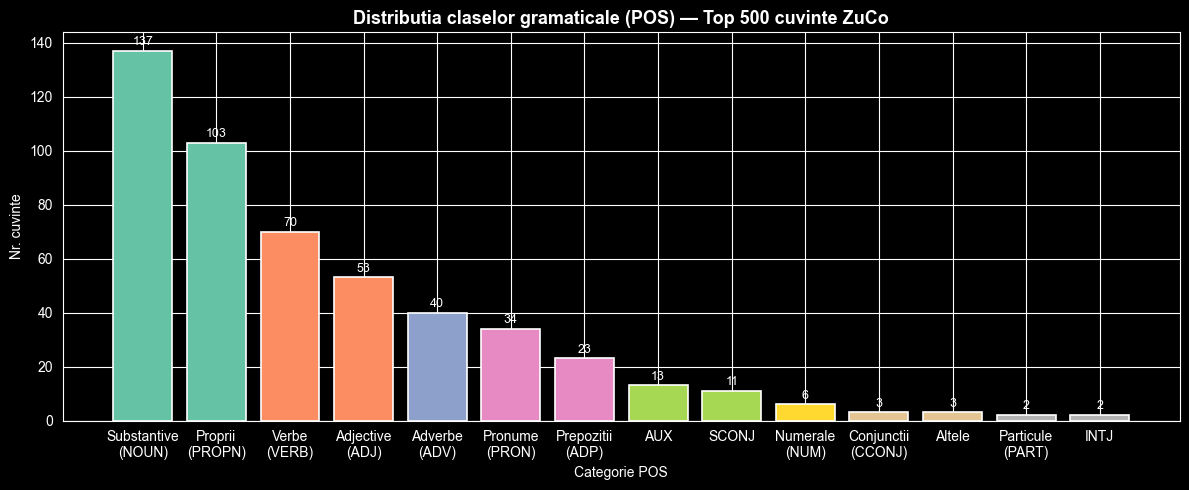

In [12]:
pos_labels = {
    'NOUN':'Substantive\n(NOUN)', 'VERB':'Verbe\n(VERB)', 'ADJ':'Adjective\n(ADJ)',
    'ADV':'Adverbe\n(ADV)', 'DET':'Determinanti\n(DET)', 'ADP':'Prepozitii\n(ADP)',
    'PRON':'Pronume\n(PRON)', 'CCONJ':'Conjunctii\n(CCONJ)', 'PART':'Particule\n(PART)',
    'PROPN':'Proprii\n(PROPN)', 'NUM':'Numerale\n(NUM)', 'X':'Altele',
}

labels = [pos_labels.get(p, p) for p, _ in pos_counter.most_common()]
values = [c for _, c in pos_counter.most_common()]
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_title('Distributia claselor gramaticale (POS) — Top 500 cuvinte ZuCo', fontsize=13, fontweight='bold')
ax.set_ylabel('Nr. cuvinte')
ax.set_xlabel('Categorie POS')
plt.tight_layout()
plt.savefig('notebooks/fig_pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
n_sem = min(10, len(pos_counter))
print(f'Clasificare SEMANTICA ({n_sem} categorii POS): chance={100/n_sem:.1f}%, target=40-60%')
print(f'Clasificare LEXICALA  (200 cuvinte):           chance={100/200:.2f}%, target Top-1=10-25%, Top-5=30-55%')
print('\nConcluzie: clasificare LEXICALA — mai informativa pentru reconstructia textuala.')

Clasificare SEMANTICA (10 categorii POS): chance=10.0%, target=40-60%
Clasificare LEXICALA  (200 cuvinte):           chance=0.50%, target Top-1=10-25%, Top-5=30-55%

Concluzie: clasificare LEXICALA — mai informativa pentru reconstructia textuala.


---
## 5. Embeddings BERT vizualizate cu t-SNE

Generam embeddings `bert-base-uncased` (CLS token) pentru top-100 cuvinte si aplicam t-SNE 2D.

In [14]:
TOP_N = 100
top_words_bert = [w for w, _ in vocab_sorted[:TOP_N]]

print(f'Generez embeddings BERT pentru {TOP_N} cuvinte...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

embeddings = []
with torch.no_grad():
    for word in top_words_bert:
        inputs = tokenizer(word, return_tensors='pt')
        out = bert_model(**inputs)
        embeddings.append(out.last_hidden_state[0, 0, :].numpy())

embeddings = np.array(embeddings)
print(f'Shape: {embeddings.shape}  (N x 768)')

Generez embeddings BERT pentru 100 cuvinte...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7160.28it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape: (100, 768)  (N x 768)


In [16]:
pos_tags_bert = [nlp(w)[0].pos_ if nlp(w) else 'X' for w in top_words_bert]

print('Aplicam t-SNE...')
emb_2d = TSNE(n_components=2, random_state=SEED, perplexity=15, max_iter=1000).fit_transform(embeddings)
print('t-SNE gata.')

Aplicam t-SNE...
t-SNE gata.


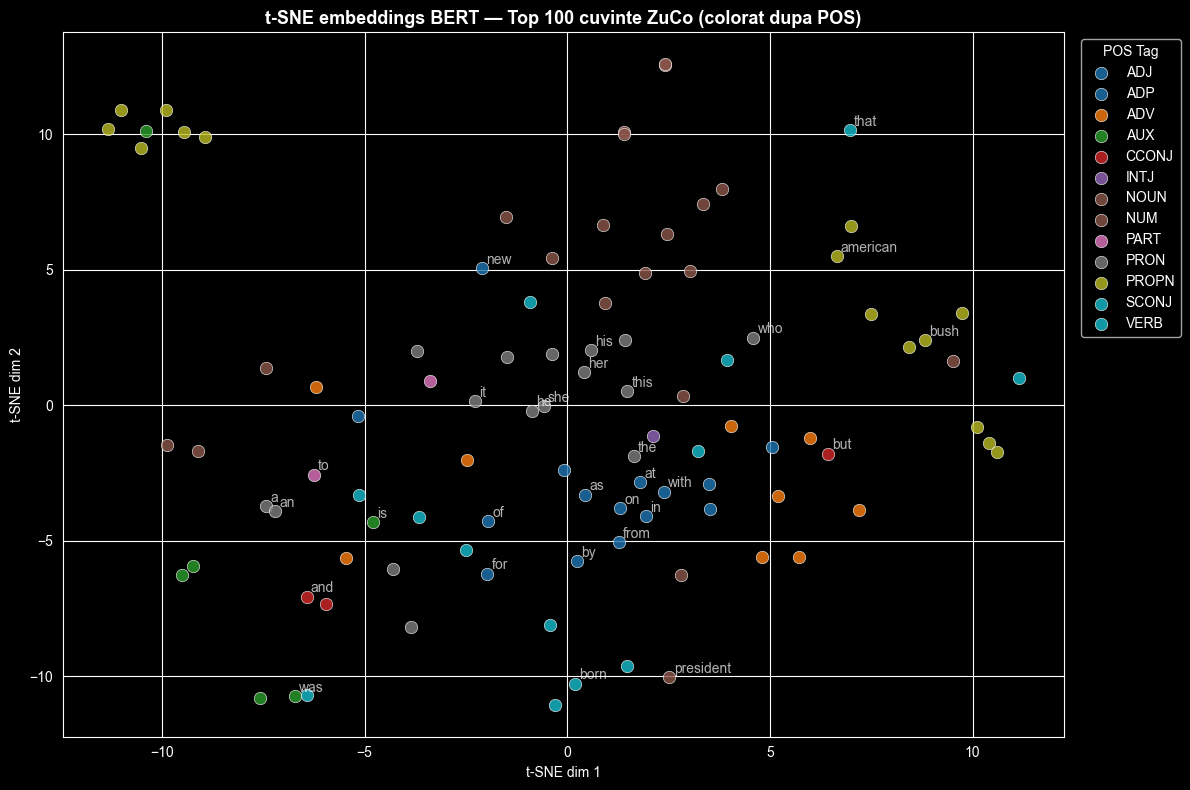

In [18]:
unique_pos = sorted(set(pos_tags_bert))
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_pos)))
pos_to_color = {p: palette[i] for i, p in enumerate(unique_pos)}

fig, ax = plt.subplots(figsize=(12, 8))
for pos in unique_pos:
    idx = [i for i, p in enumerate(pos_tags_bert) if p == pos]
    ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], c=[pos_to_color[pos]],
               label=pos, s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

for i, word in enumerate(top_words_bert[:30]):
    ax.annotate(word, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=10, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')

ax.legend(title='POS Tag', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_title('t-SNE embeddings BERT — Top 100 cuvinte ZuCo (colorat dupa POS)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('notebooks/fig_tsne_bert.png', dpi=150, bbox_inches='tight')
plt.show()

**Concluzie:** Spatiul BERT separa rezonabil categoriile semantice. Alinierea EEG → BERT prin contrastive learning (Sapt. 14, P1 + P2) este o strategie fezabila.

---
## 6. Propunere benchmark intern + generare `benchmark_config.json`

In [19]:
STOPWORDS = {
    'the','a','an','is','are','was','were','be','been','being','have','has','had',
    'do','does','did','will','would','could','should','may','might','shall','can',
    'of','in','on','at','to','for','with','by','from','as','it','its','that','this',
    'and','or','but','not','no','so','if','he','she','they','we','you','i','me',
    'him','her','us','them','my','your','his','our','their','what','which','who',
    'whom','there','when','where','how','all','each','both','more','most','also',
    'than','then','into','about','up','out','over','after','before','just','because',
    'through','during','while','same','other','such','even','only','very','well'
}

filtered_vocab = [
    w for w, c in vocab_sorted
    if w not in STOPWORDS and len(w) >= 3 and c >= 2 and w.isalpha()
][:200]

print(f'Vocabular benchmark: {len(filtered_vocab)} cuvinte')
print(f'Primele 20: {filtered_vocab[:20]}')

Vocabular benchmark: 200 cuvinte
Primele 20: ['born', 'american', 'bush', 'president', 'new', 'school', 'film', 'one', 'first', 'married', 'university', 'movie', 'united', 'states', 'family', 'john', 'york', 'college', 'son', 'january']


In [20]:
train_words, temp = train_test_split(filtered_vocab, test_size=0.30, random_state=SEED)
val_words, test_words = train_test_split(temp, test_size=0.50, random_state=SEED)

vocab_pos = {w: (nlp(w)[0].pos_ if nlp(w) else 'X') for w in filtered_vocab}

benchmark_config = {
    "version": "1.0",
    "author": "Lupse Ioan Victor",
    "description": "Configuratie benchmark comuna EEG-to-Text (Sapt. 12, PR #1)",
    "seed": SEED,
    "granularity": "word",
    "granularity_rationale": "Nivel cuvant: N400 definit per cuvant, mai multe exemple de antrenare",
    "vocab_size": len(filtered_vocab),
    "vocab_selection": "Top frecventa, excluse stopwords, min_len=3, min_freq=2",
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    "corpus": {
        "zuco1_SR":  {"file": "data/zuco1/task1-SR/preprocessed/sentencesSR.mat",  "n": len(sr)},
        "zuco1_NR":  {"file": "data/zuco1/task2-NR/preprocessed/sentencesNR.mat",  "n": len(nr)},
        "zuco1_TSR": {"file": "data/zuco1/task3-TSR/preprocessed/sentencesTSR.mat","n": len(tsr)},
        "zuco2_NR":  {"files": "data/zuco2/task_materials/nr_1..7.csv",            "n": len(nr2)},
        "zuco2_TSR": {"files": "data/zuco2/task_materials/tsr_1..7.csv",           "n": len(tsr2)},
        "total_unique": len(all_sentences)
    },
    "eeg": {
        "n_channels": 105,
        "sampling_rate_hz": 500,
        "epoch_window_ms": [-200, 800],
        "baseline_ms": [-200, 0]
    },
    "vocabulary": filtered_vocab,
    "vocabulary_pos": vocab_pos,
    "train_words": train_words,
    "val_words": val_words,
    "test_words": test_words,
    "evaluation_metrics": [
        "top1_accuracy", "top5_accuracy",
        "cosine_similarity_eeg_bert",
        "bleu1", "bleu2",
        "sentence_bert_similarity"
    ]
}

with open('benchmark_config.json', 'w', encoding='utf-8') as f:
    json.dump(benchmark_config, f, indent=2, ensure_ascii=False)

print(f'benchmark_config.json salvat.')
print(f'  Vocabular: {len(filtered_vocab)} cuvinte')
print(f'  Train/Val/Test: {len(train_words)}/{len(val_words)}/{len(test_words)}')
print(f'  Seed: {SEED} | Granularitate: word-level')

benchmark_config.json salvat.
  Vocabular: 200 cuvinte
  Train/Val/Test: 140/30/30
  Seed: 42 | Granularitate: word-level


---
## 7. Concluzii

### Corpus folosit
**~2283 propozitii unice** din ZuCo 1.0 (SR + NR + TSR) si ZuCo 2.0 (NR + TSR), dupa deduplicarea celor ~100 propozitii comune.

### Vocabular ales
**200 cuvinte** — top frecventa din corpus, fara stopwords, min 3 caractere, min frecventa 2.

### Granularitate aleasa
**Nivel cuvant** — epoch EEG [-200ms, +800ms]. Componenta N400 (~400ms) este cel mai informativ marker neural pentru procesarea semantica si este definita per cuvant in ZuCo.

### Livrabile PR #1
- `benchmark_config.json` — vocabular, split 70/15/15, seed=42
- `notebooks/fig_zipf.png`, `fig_wordcloud.png`, `fig_granularitate.png`, `fig_pos_distribution.png`, `fig_tsne_bert.png`

### Pasul urmator
Laslo Tudor Alexandru (P1) si Magdas Vlad (P2) vor importa `benchmark_config.json` in Sapt. 14.